# 6장 Applying Author Styles


## 6.1 Parsing with Functions

웹 페이지가 시각적 스타일(색상, 폰트 등)을 지정하는 가장 기본적인 방법 중 하나는 태그의 `style` 속성(Inline Style)입니다.

```html
<div style="background-color:lightblue">Blue background</div>
```

일반적으로 `style` 속성 안에는 세미콜론(`;`)으로 구분된 **CSS 프로퍼티-값 쌍(Property-Value Pairs)**들이 들어 있습니다. 브라우저는 이 CSS 문자열을 해석(파싱)하여 요소가 화면에 어떻게 렌더링될지 결정합니다.

---

### 재귀 파싱 함수 (Parsing with Functions)

복잡한 문법 파서를 한 번에 작성하는 대신, 각각의 작은 단위(공백, 단어, 기호 등)를 파싱하는 독립된 함수들을 조합해 나가는 방식을 사용합니다.  
각 파싱 함수는 텍스트를 파싱하면서 파서의 현재 위치 인덱스를 전진시키고, 파싱된 데이터를 반환합니다.
(형식 언어 이론에서는 이를 **재귀 하향 파서(Recursive Descent Parser)** 또는 **LL(1) 파서**라고 부릅니다.)

이러한 함수들을 모아 `CSSParser` 클래스를 구현하며, 파싱 대상 문자열 `self.s`와 현재 위치를 가리키는 포인터 `self.i`를 상태로 유지합니다.

#### 주요 파싱 함수 구성
- **`whitespace()`**: 공백 문자를 만나면 인덱스 `self.i`를 건너뜁니다. 공백은 의미 있는 데이터가 아니므로 아무것도 반환하지 않습니다.
- **`word()`**: 알파벳, 숫자, 특수 기호(`#`, `-`, `.`, `%`)로 이루어진 속성명이나 값을 읽어 문자열로 반환합니다. 1글자도 전진하지 못하면 유효하지 않은 단어로 간주하여 예외(`Parsing error`)를 발생시킵니다.
- **`literal(literal)`**: 콜론(`:`)이나 세미콜론(`;`) 같은 특정 구두점 문자가 현재 위치에 있는지 확인하고 `self.i`를 전진시킵니다. 일치하지 않으면 예외를 발생시킵니다.
- **`pair()`**: `word()` (속성명) + `literal(":")` + `word()` (속성값)을 차례로 호출하여 `(prop.casefold(), val)` 튜플로 반환합니다. CSS 속성명은 대소문자를 구분하지 않으므로 `casefold()`로 정규화합니다.
- **`ignore_until(chars)`**: 에러 복구 유틸리티 함수입니다. 지정한 문자 집합(`chars`) 중 하나를 만날 때까지 문자를 건너뛰며, 다음 선언문으로 안전하게 이동할 수 있게 돕습니다.
- **`body()`**: 세미콜론(`;`)으로 구분된 프로퍼티-값 쌍들을 루프로 순회하며 딕셔너리로 수집합니다.

---

### 견고성 원칙 (Robustness Principle / Postel's Law)

웹에서는 저작자의 실수로 잘못된 문법이 들어가거나, 브라우저가 아직 지원하지 않는 CSS 문법이 사용될 수 있습니다. 
만약 작은 에러 하나로 전체 파싱이 중단된다면 사용자 경험이 크게 훼손됩니다.

따라서 `body()` 메서드는 각 쌍을 파싱할 때 `try-except` 블록으로 감싸고, 실패할 경우 `ignore_until([";"])`를 사용해 다음 세미콜론까지 건너뜁니다:
> *"자신이 행하는 것은 엄격하게, 남에게서 받아들이는 것은 너그럽게"* (Postel's Law)

이를 통해 잘못된 선언문은 조용히 무시하고 정상적인 선언문들만 파싱하여 유지합니다.


In [1]:
from browser.css import CSSParser

# 1. 정상적인 CSS style 속성 파싱 테스트
parser1 = CSSParser("background-color:lightblue; font-size:16px;")
print("1. 정상 속성 파싱:")
print(parser1.body())

# 2. 대소문자 정규화(casefold) 및 공백 허용 테스트
parser2 = CSSParser("Background-Color : lightblue ;  COLOR: red; ")
print("\n2. 대소문자 정규화 및 공백 허용:")
print(parser2.body())

# 3. 잘못된 선언 건너뛰기(Postel's Law / 에러 복구 테스트)
parser3 = CSSParser("background-color: lightblue; invalid;; color: blue; font-size: 14px")
print("\n3. 잘못된 속성 건너뛰기 (에러 복구):")
print(parser3.body())

# 4. 마지막 세미콜론이 생략된 경우 파싱 테스트
parser4 = CSSParser("color: red")
print("\n4. 세미콜론 없는 단일 선언 파싱:")
print(parser4.body())


1. 정상 속성 파싱:
{'background-color': 'lightblue', 'font-size': '16px'}

2. 대소문자 정규화 및 공백 허용:
{'background-color': 'lightblue', 'color': 'red'}

3. 잘못된 속성 건너뛰기 (에러 복구):
{'background-color': 'lightblue', 'color': 'blue', 'font-size': '14px'}

4. 세미콜론 없는 단일 선언 파싱:
{'color': 'red'}


## 6.2 The `style` Attribute

`Browser.load()` 메서드에서 HTML 파싱 후, 레이아웃 계산(`DocumentLayout`)에 들어가기 직전에 `style(self.nodes)`를 호출하도록 파이프라인이 확장되었습니다.

1. `URL.request()`: 웹 페이지 HTML 다운로드
2. `HTMLParser.parse()`: HTML DOM 트리 생성
3. **`style(self.nodes)`**: CSS `style` 속성 파싱 및 스타일 딕셔너리 구성 🌟 *(새로 추가된 단계)*
4. `DocumentLayout.layout()`: 레이아웃 트리 구성 및 절대 좌표/크기 계산
5. `paint_tree()`: 페인트 커맨드(`display_list`) 수집
6. `Browser.draw()`: 화면 렌더링


In [2]:
from browser.html import HTMLParser
from browser.css import style

html_content = """<html>
  <body>
    <div style="background-color:lightblue">Blue background</div>
    <p style="background-color:yellow">Yellow paragraph</p>
    <div>No style attribute</div>
  </body>
</html>"""

# 1. HTML 파싱 후 style() 적용
nodes = HTMLParser(html_content).parse()
style(nodes)

# 2. 스타일이 부여된 DOM 트리 확인
def print_styled_tree(node, indent=0):
    name = node.tag if hasattr(node, 'tag') else repr(node.text)
    style_info = f" [style: {node.style}]" if hasattr(node, 'style') and node.style else ""
    print(" " * indent + name + style_info)
    for child in getattr(node, 'children', []):
        print_styled_tree(child, indent + 2)

print("=== Styled DOM Tree ===")
print_styled_tree(nodes)

# 3. 각 노드의 background-color 확인
div_elem = nodes.children[0].children[0]
p_elem = nodes.children[0].children[1]
plain_elem = nodes.children[0].children[2]

print("\n=== Background Colors ===")
print("div bgcolor:", div_elem.style.get("background-color", "transparent"))
print("p bgcolor:", p_elem.style.get("background-color", "transparent"))
print("plain div bgcolor:", plain_elem.style.get("background-color", "transparent"))


=== Styled DOM Tree ===
html
  body
    div [style: {'background-color': 'lightblue'}]
      'Blue background'
    p [style: {'background-color': 'yellow'}]
      'Yellow paragraph'
    div
      'No style attribute'

=== Background Colors ===
div bgcolor: lightblue
p bgcolor: yellow
plain div bgcolor: transparent


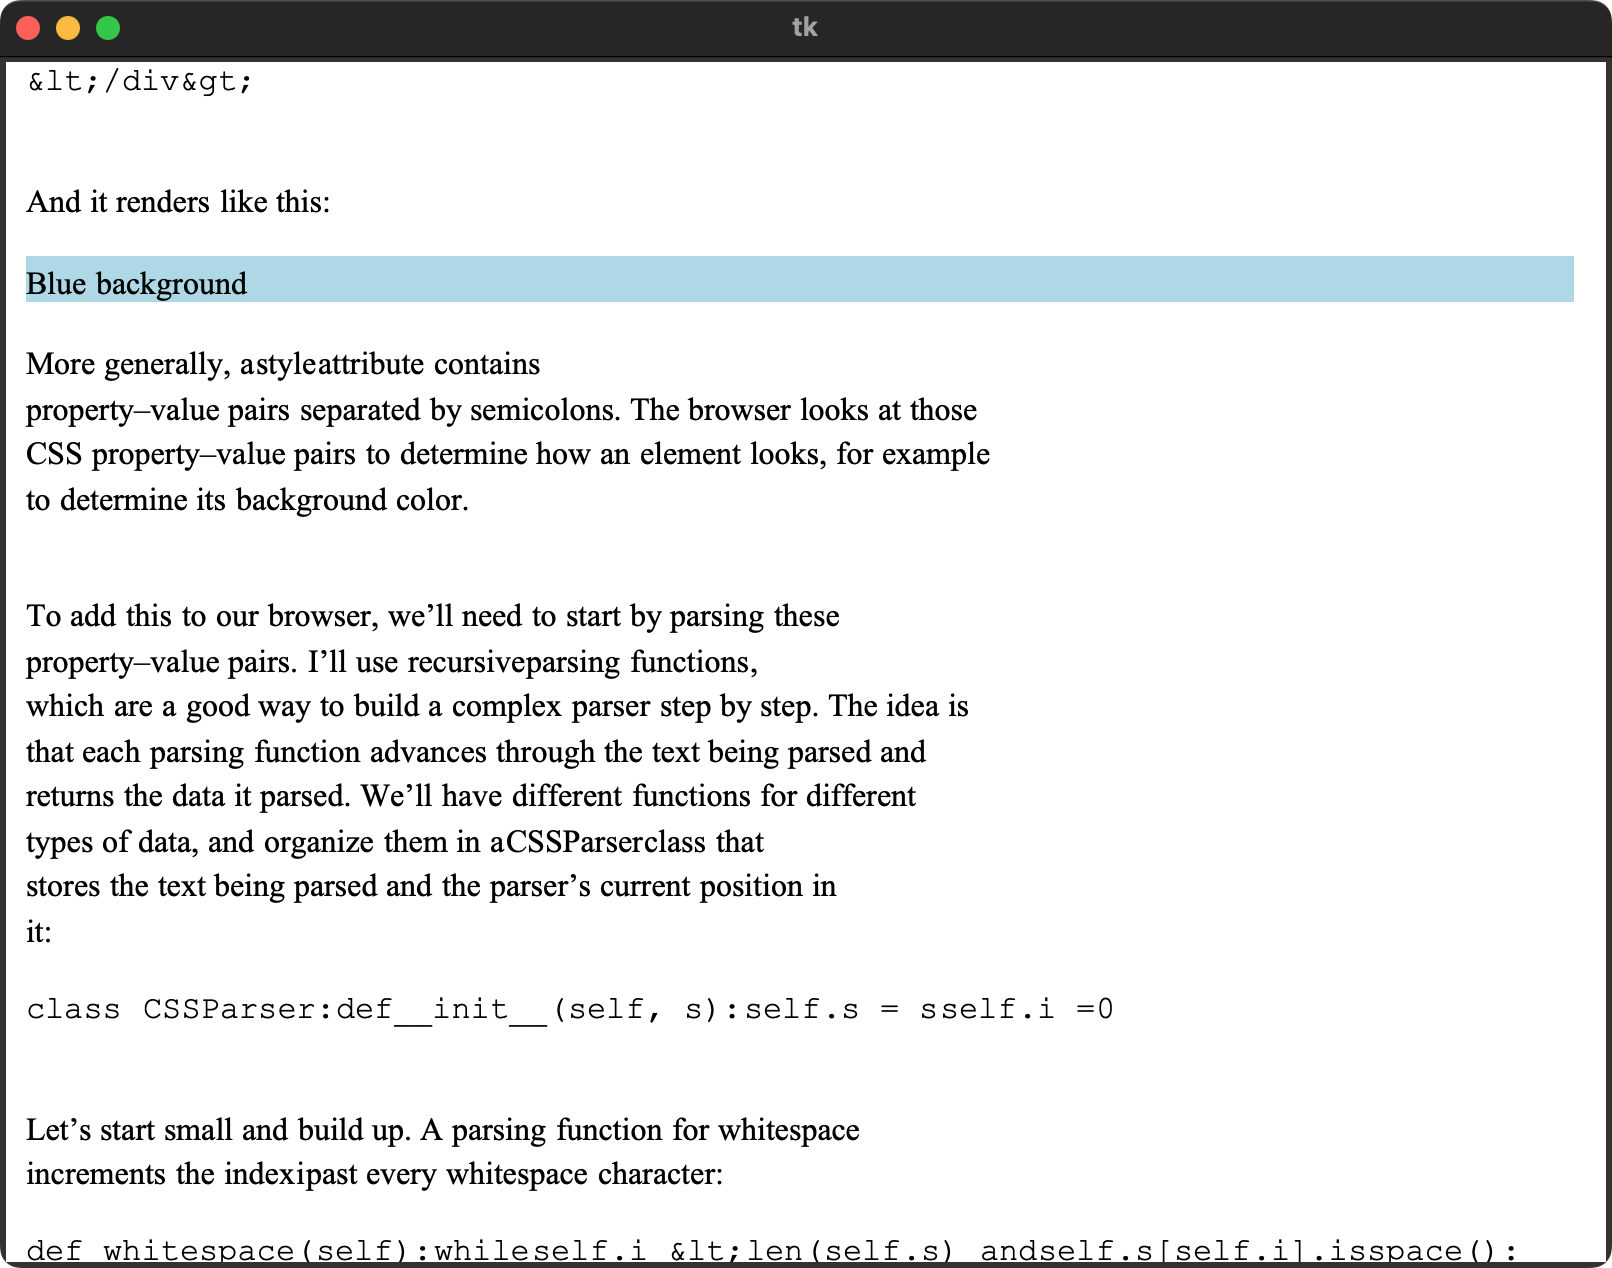

In [1]:
import time
from browser.url import URL
from browser.browser import Browser
from browser.layout import DrawRect
from browser.tk_capture import display_tk_window

url = URL("https://browser.engineering/styles.html")
browser = Browser()
browser.load(url)

# lightblue 사각형 찾기
lightblue_rects = [cmd for cmd in browser.display_list if isinstance(cmd, DrawRect) and cmd.color == "lightblue"]

if lightblue_rects:
    target = lightblue_rects[0]
    browser.scroll = max(0, target.top - 100)
    browser.draw()

# 🌟 중요: 5,800개 캔버스 아이템이 macOS 윈도우 서버에 완전히 그려지도록 강제 동기화
for _ in range(10):
    browser.window.update_idletasks()
    browser.window.update()
    time.sleep(0.05)

display_tk_window(browser.window, settle_seconds=1.0)


## 6.3 Selectors (선택자)

6.2절에서는 각 요소의 `style` 속성에 직접 적힌 인라인 CSS만 적용했습니다. 하지만 일반적인 스타일 시트(Style Sheet)는 문서 외부나 `<style>` 태그에 정의되어 문서 내의 여러 요소들을 **선택자(Selector)**를 통해 찾아내어 스타일을 일괄 지정합니다.

본 브라우저 엔진에서는 가장 기본적이면서 필수적인 **두 가지 선택자**를 지원합니다:

1. **`TagSelector` (태그 선택자)**:
   - 예: `p`는 모든 `<p>` 요소를, `div`는 모든 `<div>` 요소를 선택합니다.
   - `matches(node)`: 노드가 `Element`이고 태그 이름이 같으면 `True`를 반환합니다.
2. **`DescendantSelector` (자손 선택자)**:
   - 예: `article div`는 `article` 요소를 조상(ancestor)으로 갖는 모든 `div` 요소(descendant)를 선택합니다.
   - **좌측 결합(Left-associative)**: `a b c`는 `(a b) c`로 해석됩니다. 즉, `<a>`의 자손인 `<b>`의 자손인 `<c>`를 의미합니다.
   - `matches(node)`: 자손 선택자가 현재 노드와 일치하면 `while node.parent:`로 부모 체인을 거슬러 올라가며 조상 선택자가 일치하는지 검사합니다.

---

### 💡 CSS 파일 규칙 파싱과 견고성(Postel's Law)
- `CSSParser.parse()`는 `selector { body }` 형태의 규칙을 순차적으로 파싱하여 `(selector, body)` 튜플들의 리스트를 반환합니다.
- **에러 복구**:
  - 선택자 파싱 도중 오류가 발생하면 `ignore_until(["}"])`로 해당 블록 전체를 건너뛰고 다음 규칙을 정상 파싱합니다.
  - `body()` 파싱 도중 속성 오류가 발생하면 `ignore_until([";", "}"])`로 해당 속성만 건너뛰고 블록 내 다음 속성이나 다음 규칙으로 복구합니다.


In [1]:
from browser.css import CSSParser, TagSelector, DescendantSelector

# 1. CSS 스타일 시트 파싱
css_source = """
p { color: red; }
div p { color: blue; }
article section p { color: green; }
"""

rules = CSSParser(css_source).parse()

print(f"=== 파싱된 규칙 목록 (총 {len(rules)}개) ===")
for idx, (selector, body) in enumerate(rules, 1):
    print(f"[{idx}] 선택자: {selector}")
    print(f"    속성들: {body}")


=== 파싱된 규칙 목록 (총 3개) ===
[1] 선택자: TagSelector(tag='p')
    속성들: {'color': 'red'}
[2] 선택자: DescendantSelector(ancestor=TagSelector(tag='div'), descendant=TagSelector(tag='p'))
    속성들: {'color': 'blue'}
[3] 선택자: DescendantSelector(ancestor=DescendantSelector(ancestor=TagSelector(tag='article'), descendant=TagSelector(tag='section')), descendant=TagSelector(tag='p'))
    속성들: {'color': 'green'}


In [2]:
from browser.html import HTMLParser
from browser.css import CSSParser

# 2. DOM 트리 구성 및 선택자 매칭(matches) 테스트
html_doc = """<html>
  <body>
    <article>
      <section>
        <div>
          <p id="target1">Article Section Div P</p>
        </div>
      </section>
    </article>
    <span>
      <p id="target2">Span P</p>
    </span>
  </body>
</html>"""

dom = HTMLParser(html_doc).parse()

# 각 P 노드 추출
p1 = dom.children[0].children[0].children[0].children[0].children[0] # article 안쪽 p
p2 = dom.children[0].children[1].children[0]                          # span 안쪽 p

rules = CSSParser("""
  p { font-size: 16px; }
  div p { color: blue; }
  article section p { font-weight: bold; }
""").parse()

print("=== 선택자 매칭 결과 검증 ===")
for selector, _ in rules:
    print(f"선택자: {selector}")
    print(f"  - target1 (article section div p) 매칭 여부: {selector.matches(p1)}")
    print(f"  - target2 (span p)                매칭 여부: {selector.matches(p2)}")


=== 선택자 매칭 결과 검증 ===
선택자: TagSelector(tag='p')
  - target1 (article section div p) 매칭 여부: True
  - target2 (span p)                매칭 여부: True
선택자: DescendantSelector(ancestor=TagSelector(tag='div'), descendant=TagSelector(tag='p'))
  - target1 (article section div p) 매칭 여부: True
  - target2 (span p)                매칭 여부: False
선택자: DescendantSelector(ancestor=DescendantSelector(ancestor=TagSelector(tag='article'), descendant=TagSelector(tag='section')), descendant=TagSelector(tag='p'))
  - target1 (article section div p) 매칭 여부: True
  - target2 (span p)                매칭 여부: False


In [3]:
from browser.css import CSSParser

# 3. 문법 오류가 포함된 CSS 파싱 및 에러 복구 검증
# (참고: 현재 CSSParser는 /* */ 주석을 파싱하지 않으므로 순수 CSS 구문으로 테스트합니다)
faulty_css = """
@invalid-rule { color: red; }

p { background-color: yellow; }

div {
  valid-prop: 10px;
  bad declaration without colon;
  background-color: lightblue;
}
"""

recovered_rules = CSSParser(faulty_css).parse()
print(f"=== 에러 복구 후 성공적으로 추출된 규칙: {len(recovered_rules)}개 ===")
for selector, body in recovered_rules:
    print(f"- 선택자: {selector} -> 속성: {body}")


=== 에러 복구 후 성공적으로 추출된 규칙: 2개 ===
- 선택자: TagSelector(tag='p') -> 속성: {'background-color': 'yellow'}
- 선택자: TagSelector(tag='div') -> 속성: {'valid-prop': '10px', 'background-color': 'lightblue'}


## 6.4 Applying Style Sheets (스타일 시트 적용)

1. **규칙 일괄 적용 (`style(node, rules)`)**:

2. **브라우저 기본 스타일시트 (User Agent Style Sheet)**:

3. **트리 평탄화 유틸리티 (`tree_to_list`)**:

4. **상대 URL 해석 (`URL.resolve`)**:

5. **외부 스타일시트 다운로드 및 적용 (`Browser.load`)**:


In [11]:
from browser.url import URL

base_url = URL("https://browser.engineering/styles/main.html")

print(f"기준 URL: {base_url.scheme}://{base_url.host}:{base_url.port}{base_url.path}")
print("-" * 60)

# 1. 절대 URL (이미 완전한 URL인 경우)
abs_url = base_url.resolve("https://example.com/assets/vendor.css")
print("1. 절대 URL:", f"{abs_url.scheme}://{abs_url.host}:{abs_url.port}{abs_url.path}")

# 2. 호스트 상대 URL (루트 /로 시작)
host_rel_url = base_url.resolve("/css/global.css")
print("2. 호스트 상대 URL (/):", f"{host_rel_url.scheme}://{host_rel_url.host}:{host_rel_url.port}{host_rel_url.path}")

# 3. 경로 상대 URL (현재 디렉터리 기준)
path_rel_url = base_url.resolve("theme.css")
print("3. 경로 상대 URL (파일명):", f"{path_rel_url.scheme}://{path_rel_url.host}:{path_rel_url.port}{path_rel_url.path}")

# 4. 상위 디렉터리 경로 (../)
parent_rel_url = base_url.resolve("../shared/layout.css")
print("4. 상위 디렉터리 (../):", f"{parent_rel_url.scheme}://{parent_rel_url.host}:{parent_rel_url.port}{parent_rel_url.path}")

# 5. 스킴 상대 URL (//)
scheme_rel_url = base_url.resolve("//cdn.jsdelivr.net/npm/style.css")
print("5. 스킴 상대 URL (//):", f"{scheme_rel_url.scheme}://{scheme_rel_url.host}:{scheme_rel_url.port}{scheme_rel_url.path}")


기준 URL: https://browser.engineering:443/styles/main.html
------------------------------------------------------------
1. 절대 URL: https://example.com:443/assets/vendor.css
2. 호스트 상대 URL (/): https://browser.engineering:443/css/global.css
3. 경로 상대 URL (파일명): https://browser.engineering:443/styles/theme.css
4. 상위 디렉터리 (../): https://browser.engineering:443/shared/layout.css
5. 스킴 상대 URL (//): https://cdn.jsdelivr.net:443/npm/style.css


In [12]:
from browser.html import HTMLParser, Element, tree_to_list
from browser.css import DEFAULT_STYLE_SHEET, style, TagSelector

sample_html = """<!doctype html>
<html>
  <head>
    <link rel="stylesheet" href="/assets/style.css">
  </head>
  <body>
    <h1>문서 제목</h1>
    <pre>브라우저 기본 스타일시트(browser.css)에 의해 gray 배경이 지정되는 코드 블록</pre>
    <pre style="background-color:lightblue">인라인 style 속성에 의해 lightblue로 덮어씌워지는 코드 블록</pre>
    <p>단락 텍스트</p>
  </body>
</html>"""

doc = HTMLParser(sample_html).parse()

# 1. tree_to_list를 활용한 <link rel="stylesheet"> 태그 추출
stylesheet_links = [
    node.attributes["href"]
    for node in tree_to_list(doc, [])
    if isinstance(node, Element)
    and node.tag == "link"
    and node.attributes.get("rel") == "stylesheet"
    and "href" in node.attributes
]
print("=== 1. 발견된 스타일시트 링크 ===")
print(stylesheet_links)

# 2. 브라우저 기본 스타일시트 복사 및 저자 스타일 규칙 추가
rules = DEFAULT_STYLE_SHEET.copy()
rules.append((TagSelector("h1"), {"color": "navy"}))
rules.append((TagSelector("p"), {"color": "green"}))

# 3. 스타일 적용 (규칙 적용 후 inline style 덮어쓰기)
style(doc, rules)

print("\n=== 2. 각 요소별 최종 계산된 style 딕셔너리 ===")
for node in tree_to_list(doc, []):
    if isinstance(node, Element) and node.tag in ["h1", "pre", "p"]:
        inline_note = " (인라인 오버라이드)" if "style" in node.attributes else ""
        print(f"<{node.tag}>{inline_note}: {node.style}")


=== 1. 발견된 스타일시트 링크 ===
['/assets/style.css']

=== 2. 각 요소별 최종 계산된 style 딕셔너리 ===
<h1>: {'color': 'navy'}
<pre>: {'background-color': 'gray'}
<pre> (인라인 오버라이드): {'background-color': 'lightblue'}
<p>: {'color': 'green'}


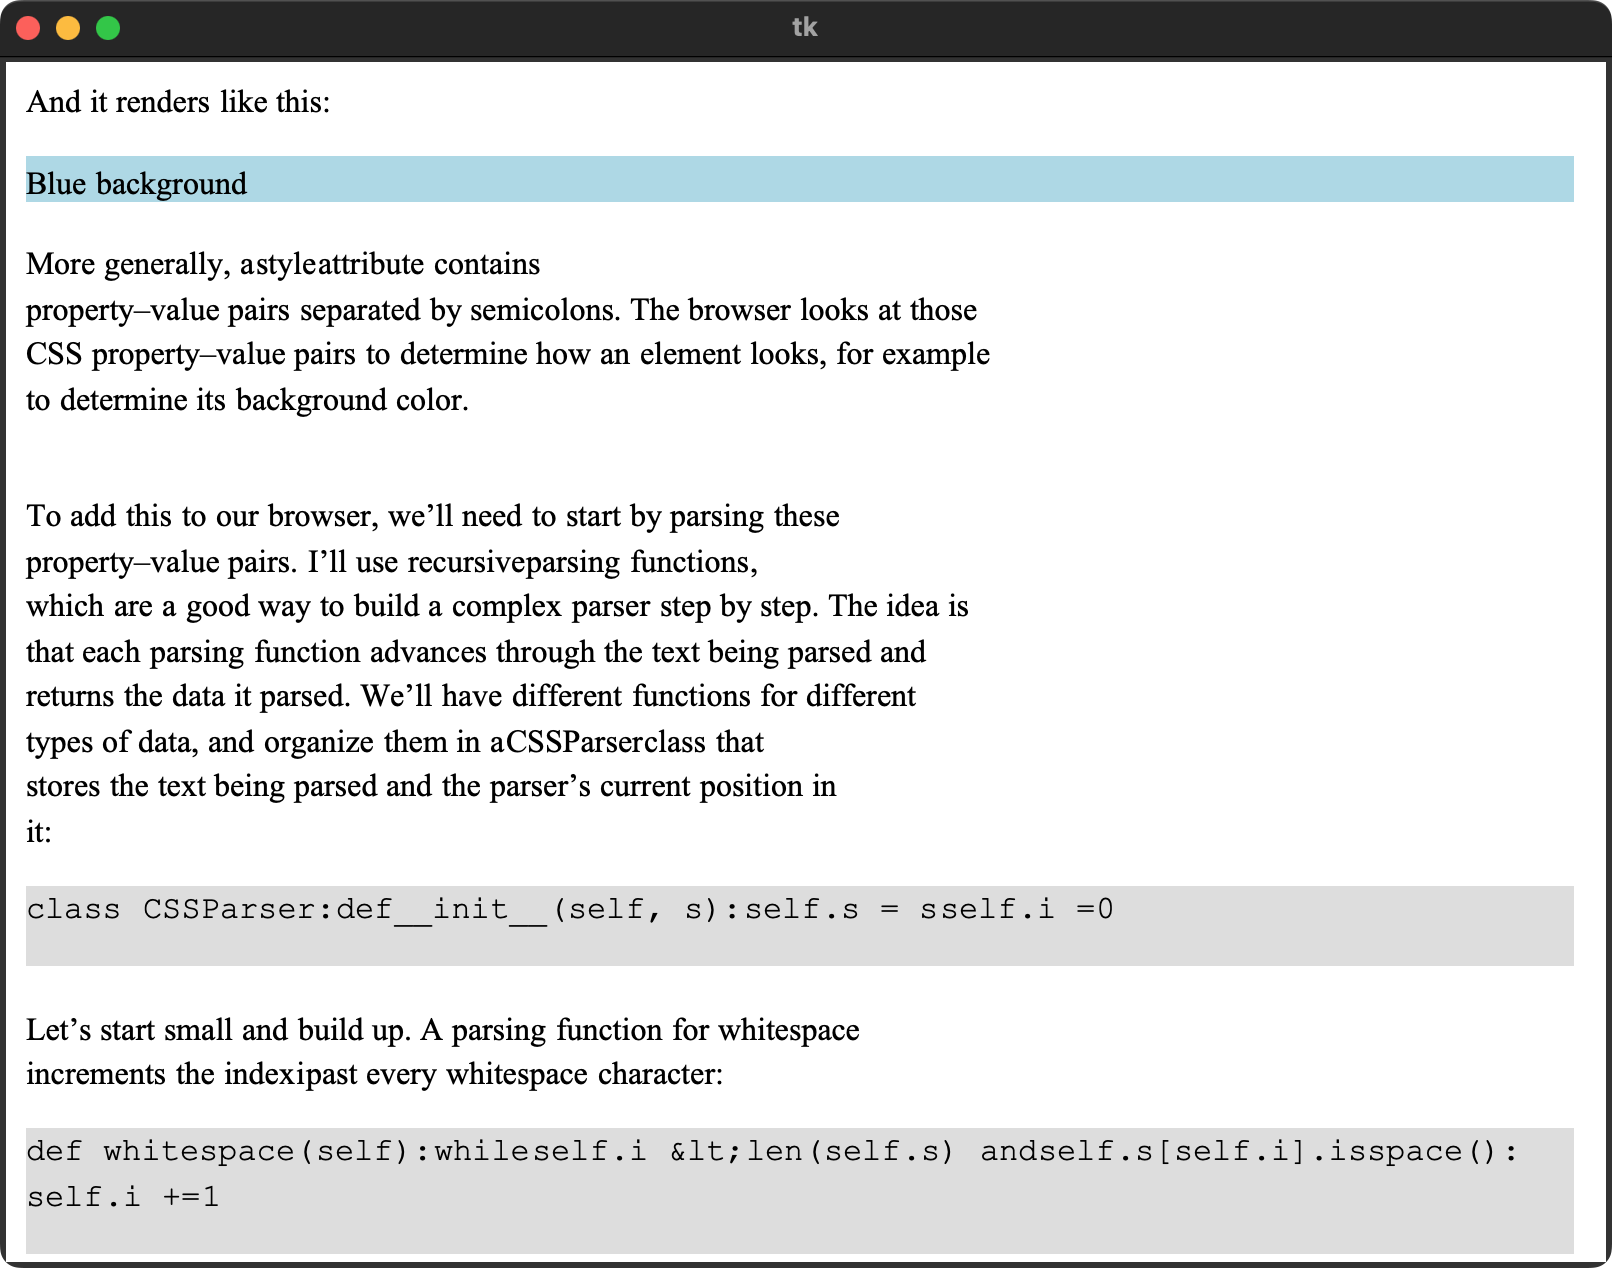

In [1]:
import time
from browser.url import URL
from browser.browser import Browser
from browser.layout import DrawRect
from browser.tk_capture import display_tk_window

# 6.4절 구현에 따라 Browser.load()는:
# 1) browser.css의 DEFAULT_STYLE_SHEET (pre 배경 gray)
# 2) 페이지 내 <link rel="stylesheet"> 외부 스타일시트 다운로드 및 파싱
# 3) style(self.nodes, rules) 적용

url = URL("https://browser.engineering/styles.html")
browser = Browser()
browser.load(url)

gray_rects = [cmd for cmd in browser.display_list if isinstance(cmd, DrawRect) and cmd.color == "gray"]
lightblue_rects = [cmd for cmd in browser.display_list if isinstance(cmd, DrawRect) and cmd.color == "lightblue"]

# 상단 부분(lightblue 및 pre 코드 블록이 보이는 위치)으로 스크롤
if lightblue_rects:
    target = lightblue_rects[0]
    browser.scroll = max(0, target.top - 50)
    browser.draw()

# 렌더링 동기화 후 화면 캡처 표시
for _ in range(10):
    browser.window.update_idletasks()
    browser.window.update()
    time.sleep(0.05)

display_tk_window(browser.window, settle_seconds=1.0)
